In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


In [ ]:
df=pd.read_excel("../data/Data_Train.xlsx")

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

display the null rows

In [ ]:
df[df.isnull().any(axis=1)]

In [ ]:
df.dropna(axis=0,inplace=True)
df.isnull().sum()

In [ ]:
df.dtypes

In [ ]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'],format='%d/%m/%Y')
df['Journey_day']=df['Date_of_Journey'].dt.day
df['Journey_month']=df['Date_of_Journey'].dt.strftime('%b')
df['Journey_year']=df['Date_of_Journey'].dt.year

df.drop(['Date_of_Journey'],axis=1,inplace=True)


In [ ]:
df['Dep_Time']=pd.to_datetime(df['Dep_Time'],format='%H:%M')

In [ ]:
df['Time_Period'] = np.select(
    [
        df['Dep_Time'].dt.hour.between(0,4),
        df['Dep_Time'].dt.hour.between(5, 11),
        df['Dep_Time'].dt.hour.between(12, 15),
        df['Dep_Time'].dt.hour.between(16, 20)
    ],
    [   'Early Morning',
        'Morning',
        'Noon',
        'Evening'
    ],
    default='Night'
)

df['Dep_Time']=pd.to_datetime(df['Dep_Time'],format='%H:%M').dt.time

In [ ]:
df['Total_Stops']=df['Total_Stops'].replace({'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4})

In [ ]:
df['Arrival_Time']=df['Arrival_Time'].str.replace(r'\s+\d{1,2}\s+[a-zA-Z]{3}','',regex=True)
df['Arrival_Time']=pd.to_datetime(df['Arrival_Time'],format='%H:%M').dt.time

In [ ]:
# replace No Info to No info 
df['Additional_Info']=df['Additional_Info'].str.replace('No Info','No info')

Exploratory Data Analysis

In [427]:
def generate_hex_color()->str:
    return "#{:06x}".format(random.randint(0, 0xFFFFFF)) 

def flights_count(df:pd.DataFrame,cols:str)->pd.DataFrame:
    return [df[col].value_counts().to_frame('count').reset_index() for col in cols]

def total_price(df:pd.DataFrame,cols:str)->pd.DataFrame:
        return [df.groupby(col)['Price'].agg('mean').round(2).reset_index() for col in cols]

def create_bar_charts(datas:dict[str,pd.DataFrame]|pd.DataFrame,color:str='yellow')->None:
    if not isinstance(datas,list):
         datas=[datas]
    fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(16,10))
    sns.set_theme(style="whitegrid")
    for ax,data in zip(axes.flat,datas):
        col_names=list(data.columns)
        sns.barplot(data=data,x=col_names[0],y=col_names[1],color=color,ax=ax)
        ax.set_title(col_names[0])
        ax.tick_params(axis='x',labelrotation=90)
        # for p in ax.patches:
        #     ax.annotate(int(p.get_height()), (p.get_x()+0.25, p.get_height()+1), va='bottom',
        #                     color= 'black')
        for container in ax.containers:
            ax.bar_label(
                container,
                label_type='center',  
                fmt='%.0f',
                color='black',
                fontsize=9
            )
    plt.tight_layout()
    plt.show()
    

        


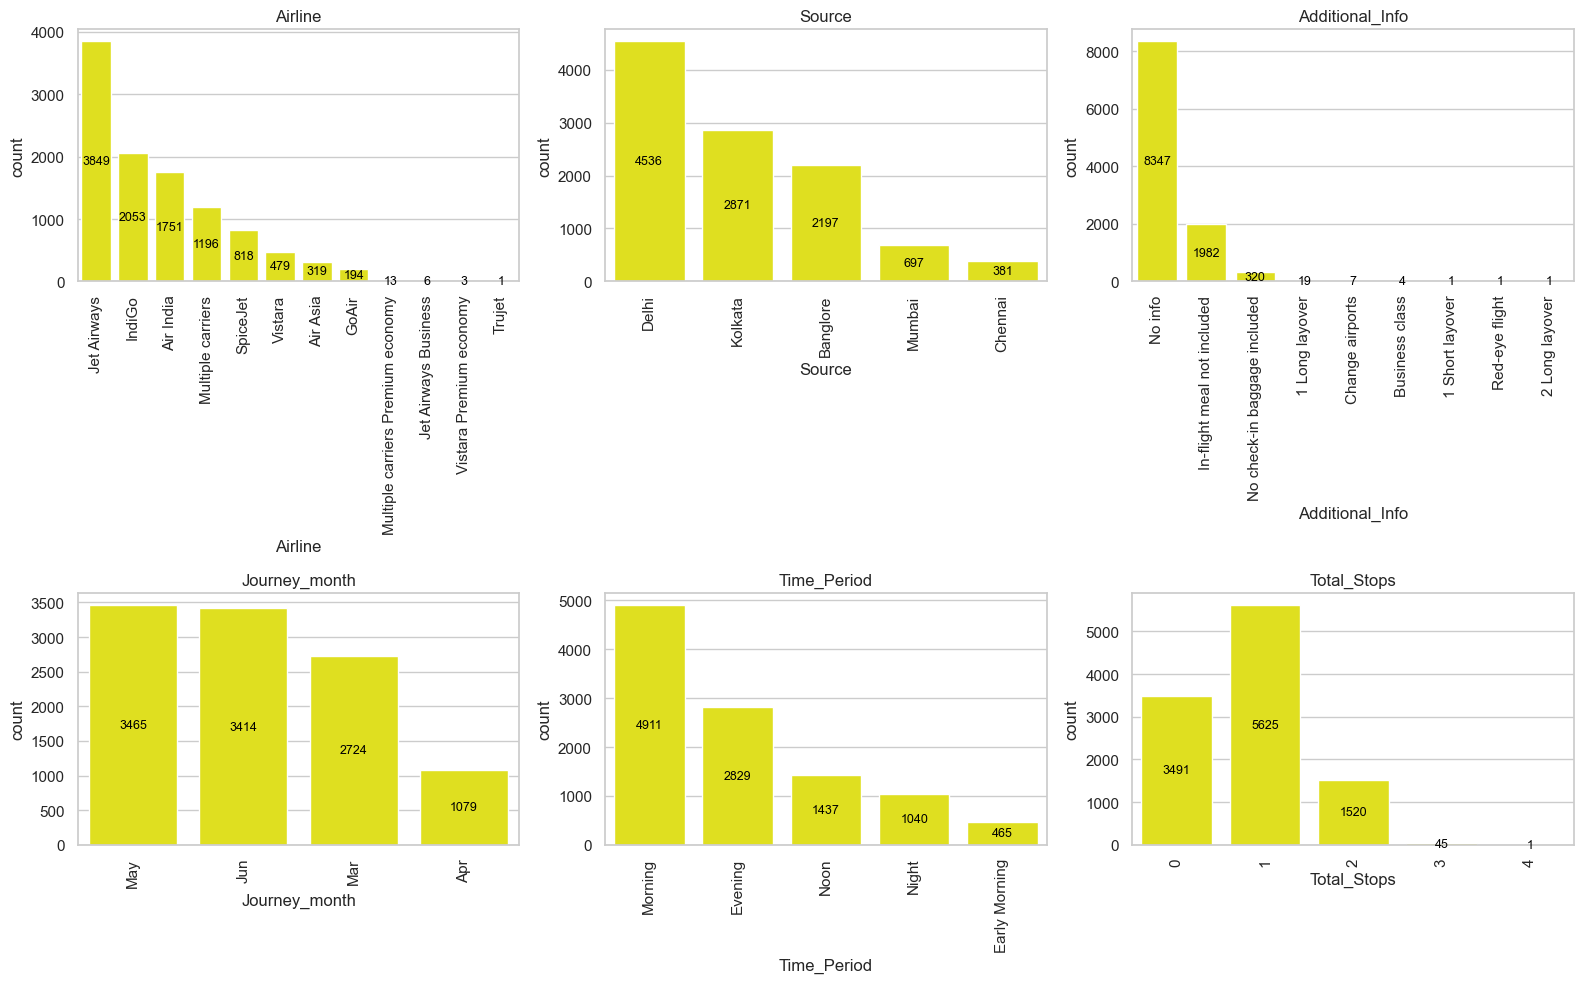

In [428]:
cols=['Airline','Source','Additional_Info','Journey_month','Time_Period','Total_Stops']
datas=flights_count(df,cols)
create_bar_charts(datas)



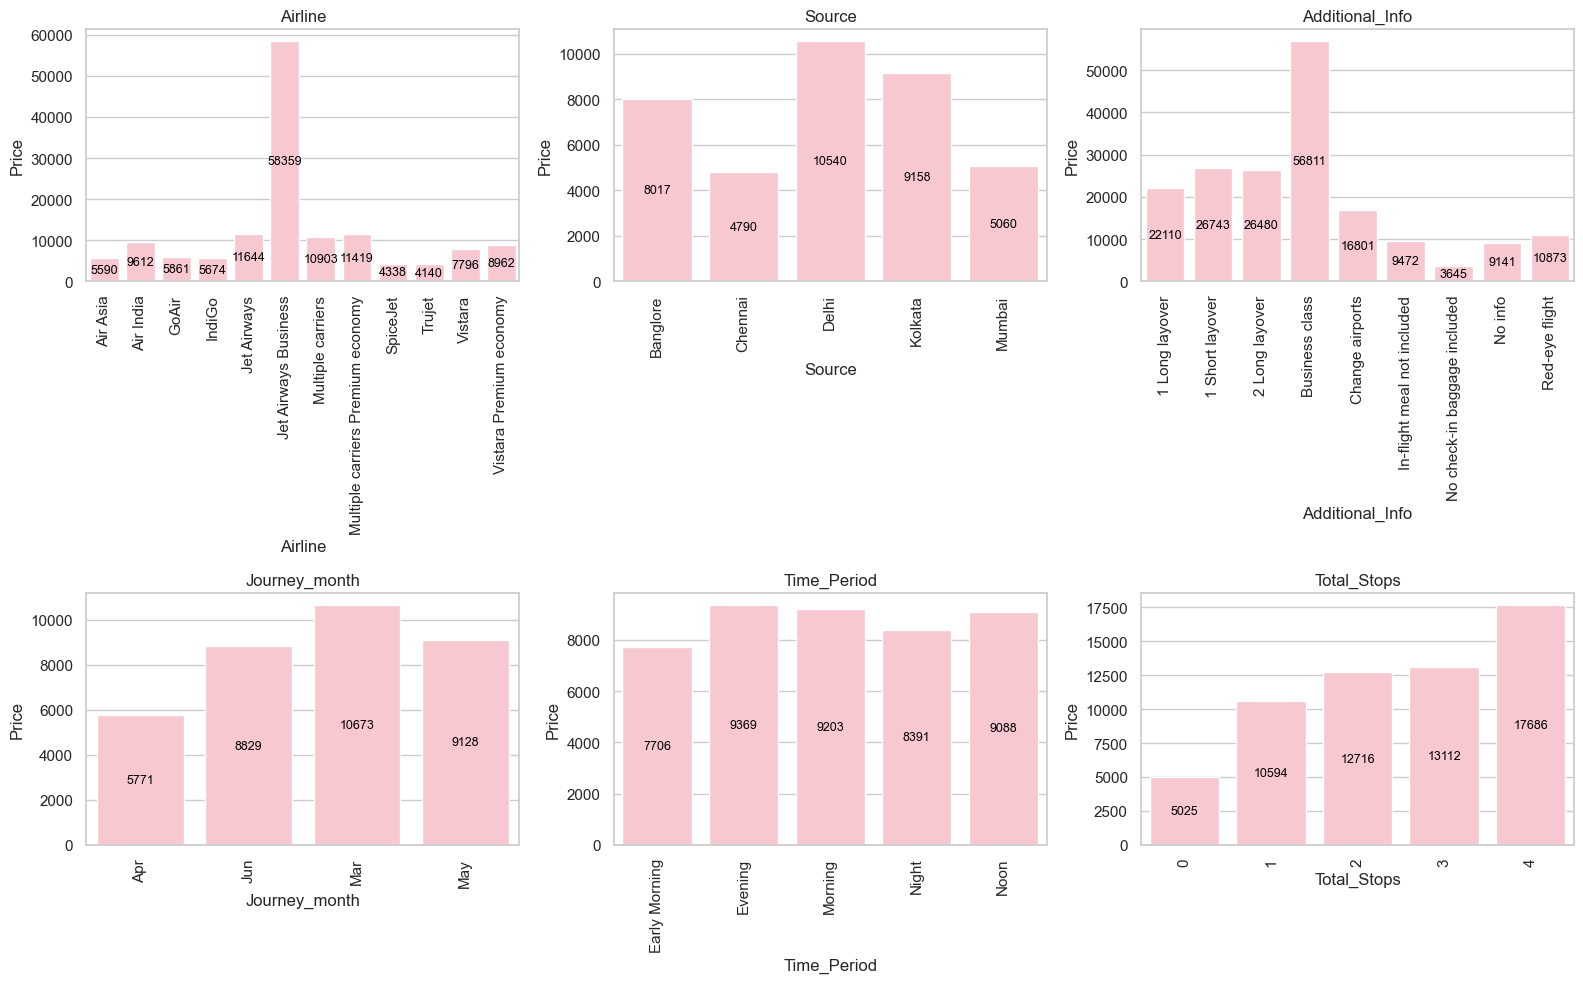

In [430]:
cols=['Airline','Source','Additional_Info','Journey_month','Time_Period','Total_Stops']
datas=total_price(df,cols)
create_bar_charts(datas,color='pink')

